### Task VI: Quantum representation learning
In this task you should implement a simple representation learning scheme based on a contrastive loss:
- Load the MNIST dataset
- Write a function which takes an image and prepares a quantum state. This function should have trainable parameters which we want to learn in order to have good quantum representations
- Create a circuit with which takes two images and embeds both as quantum states with the function you wrote before. Afterwards the circuit should perform a SWAP test between the two states.
- In the end the measurement should give the fidelity of the quantum states.
- Train the circuit parameters with a contrastive loss: For two MNIST images in the same class the fidelity should be maximized, while for images of different classes the fidelity should be minimized.


In [1]:
!pip install pennylane

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import pennylane as qml
import numpy as np
from sklearn.decomposition import PCA

In [3]:
torch.set_default_dtype(torch.float64)

In [4]:
# 1. Hyperparameters
n_qubits = 6        # Matches PCA components
n_layers = 2
batch_size = 16
lr = 0.02           # Slightly higher for Adam
epochs = 10
n_samples = 500     # Total subset size

Images can have hundreds or thousands of values to encode an image, we perform PCA to decrease the number of pixels to the number of qubits in the circuit. In our case 6 qubits.

In [5]:
# 2. Data & PCA (FIXED)
# Load raw MNIST to perform PCA
raw_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True)
x_raw = raw_dataset.data[:n_samples].reshape(n_samples, -1).numpy() / 255.0
y_raw = raw_dataset.targets[:n_samples]

# Apply PCA to get the 'n_qubits' most important features
pca = PCA(n_components=n_qubits)
x_pca = pca.fit_transform(x_raw)

# Re-scale PCA components to [0, pi] for quantum rotation angles
x_pca = (x_pca - x_pca.min()) / (x_pca.max() - x_pca.min()) * np.pi
x_train = torch.tensor(x_pca)
y_train = y_raw

# Group indices for balanced sampling
class_indices = {i: (y_train == i).nonzero(as_tuple=True)[0] for i in range(10)}

In [6]:
# 3. Quantum Device & Circuit
dev = qml.device("default.qubit", wires=2*n_qubits + 1)

def embedding(x, weights, wires):
    # Data encoding using PCA components
    for i in range(n_qubits):
        qml.RY(x[i], wires=wires[i])
        qml.RZ(x[i], wires=wires[i])

    # Trainable layers
    for l in range(n_layers):
        for i in range(n_qubits):
            qml.RY(weights[l, i], wires=wires[i])
        # Entanglement
        for i in range(n_qubits):
            qml.CNOT(wires=[wires[i], wires[(i+1) % n_qubits]])

In [7]:
example_circuit = qml.QNode(embedding, dev)
print(qml.draw(example_circuit)(x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6], weights=torch.tensor([[0.1, 0.2, 0.3, 0.4, 0.5, 0.6], [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]]), wires=list(range(n_qubits))))

0: ──RY(0.10)──RZ(0.10)──RY(0.10)─╭●─────────────╭X──RY(0.10)─╭●─────────────╭X─┤  
1: ──RY(0.20)──RZ(0.20)──RY(0.20)─╰X─╭●──────────│───RY(0.20)─╰X─╭●──────────│──┤  
2: ──RY(0.30)──RZ(0.30)──RY(0.30)────╰X─╭●───────│───RY(0.30)────╰X─╭●───────│──┤  
3: ──RY(0.40)──RZ(0.40)──RY(0.40)───────╰X─╭●────│───RY(0.40)───────╰X─╭●────│──┤  
4: ──RY(0.50)──RZ(0.50)──RY(0.50)──────────╰X─╭●─│───RY(0.50)──────────╰X─╭●─│──┤  
5: ──RY(0.60)──RZ(0.60)──RY(0.60)─────────────╰X─╰●──RY(0.60)─────────────╰X─╰●─┤  


The SWAP test measures the similarity (fidelity) between two quantum states by using an ancilla qubit to control a swap operation between them. When the two states are identical, the ancilla's interference remains constructive, resulting in a measurement of $|0\rangle$. If the states are different, the ancilla enters a mixed state, and the decrease in the expectation value $\langle Z \rangle$ directly quantifies the distance between the two images in the Hilbert space.

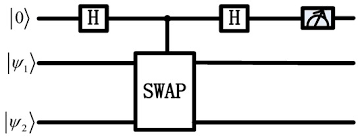

In [8]:
@qml.qnode(dev, interface="torch")
def swap_test(x1, x2, weights):
    anc = 0
    w1 = list(range(1, n_qubits+1))
    w2 = list(range(n_qubits+1, 2*n_qubits+1))

    embedding(x1, weights, w1)
    embedding(x2, weights, w2)

    qml.Hadamard(wires=anc)
    for i in range(n_qubits):
        qml.CSWAP(wires=[anc, w1[i], w2[i]])
    qml.Hadamard(wires=anc)
    return qml.expval(qml.PauliZ(anc))


In [9]:
# 4. Model & Contrastive Margin Loss
class QuantumRepModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Initialize with small weights to avoid barren plateaus
        self.weights = nn.Parameter(torch.randn(n_layers, n_qubits) * 0.1)

    def forward(self, x1, x2):
        expval = swap_test(x1, x2, self.weights)
        return (1 + expval) / 2 # Fidelity

def contrastive_margin_loss(f, same, margin=0.3):
    # Pull same classes: maximize fidelity (min 1-f)
    pos_loss = same * (1 - f)
    # Push different classes: minimize fidelity until it hits margin
    neg_loss = (1 - same) * torch.relu(f - margin)
    return torch.mean(pos_loss + neg_loss)

model = QuantumRepModel()
optimizer = optim.Adam(model.parameters(), lr=lr)

The fidelity will be printed for these two images after training. If they are of same label their fidelity after training will become more near to 1. Else more near to 0.

In [11]:
# 5. Training Loop
print(f"Starting training with PCA-reduced features ({n_qubits} qubits)...")

for epoch in range(epochs):
    epoch_loss = 0
    # Process in manual batches
    permutation = torch.randperm(n_samples)

    for i in range(0, n_samples, batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = x_train[indices]
        batch_y = y_train[indices]

        # Sample balanced pairs
        x1_list, x2_list, same_list = [], [], []
        for j in range(len(batch_x)):
            x1 = batch_x[j]
            y1 = batch_y[j].item()

            if torch.rand(1).item() < 0.5: # 50% Positive
                idx2 = np.random.choice(class_indices[y1])
                same = 1.0
            else: # 50% Negative
                other_c = np.random.choice([c for c in range(10) if c != y1])
                idx2 = np.random.choice(class_indices[other_c])
                same = 0.0

            x1_list.append(x1)
            x2_list.append(x_train[idx2])
            same_list.append(same)

        optimizer.zero_grad()
        fids = torch.stack([model(x1_list[k], x2_list[k]) for k in range(len(x1_list))])

        loss = contrastive_margin_loss(fids, torch.tensor(same_list))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/(n_samples/batch_size):.4f} | Avg Fid: {fids.mean().item():.3f}")

print("Test Check after training")
# Positive test
f_pos = model(x_train[class_indices[0][0]], x_train[class_indices[0][1]]).item()
# Negative test
f_neg = model(x_train[class_indices[0][0]], x_train[class_indices[1][0]]).item()
print(f"Same Class (0 vs 0) Fidelity: {f_pos:.4f}")
print(f"Diff Class (0 vs 1) Fidelity: {f_neg:.4f}")

Starting training with PCA-reduced features (6 qubits)...
Epoch 1/10 | Loss: 0.3049 | Avg Fid: 0.720
Epoch 2/10 | Loss: 0.2840 | Avg Fid: 0.799
Epoch 3/10 | Loss: 0.2840 | Avg Fid: 0.761
Epoch 4/10 | Loss: 0.2872 | Avg Fid: 0.897
Epoch 5/10 | Loss: 0.3008 | Avg Fid: 0.816
Epoch 6/10 | Loss: 0.3071 | Avg Fid: 0.888
Epoch 7/10 | Loss: 0.2952 | Avg Fid: 0.718
Epoch 8/10 | Loss: 0.2984 | Avg Fid: 0.731
Epoch 9/10 | Loss: 0.2855 | Avg Fid: 0.745
Epoch 10/10 | Loss: 0.2953 | Avg Fid: 0.693
Test Check after training
Same Class (0 vs 0) Fidelity: 0.9807
Diff Class (0 vs 1) Fidelity: 0.5426
